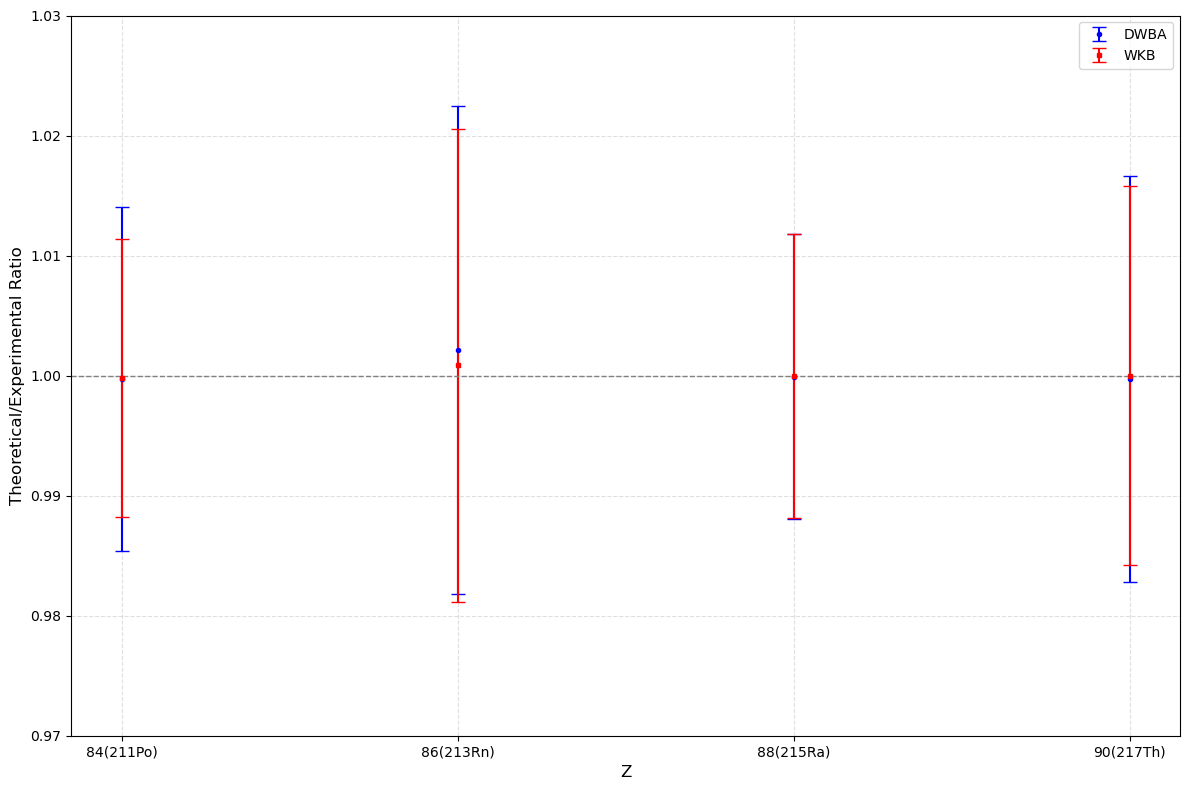

In [19]:
import numpy as np
import matplotlib.pyplot as plt


Sys=['211Po','213Rn','215Ra','217Th']
Z=[84,86,88,90]
T_half_expt=[0.516,19.36e-3,1.68e-3,254e-6]
T_half_calc_dwba=[0.515853576464293,0.01940080074073156,0.0016798746921742062,0.00025393277540573426]
T_half_2sigma_dwba=[0.007384161900277197,0.0003937785991267398,1.999598301277089e-05,4.292253948313664e-06]

T_half_calc_wkb=[0.5158905614040402,0.019376367726007926,0.0016799052057963173,0.0002540000639797968]
T_half_2sigma_wkb=[0.005965097512233266,0.0003818913474164974,1.9873828913767867e-05,4.0074559194984095e-06]




# 计算两种模型的比值和误差
ratios_dwba = [calc/expt for calc, expt in zip(T_half_calc_dwba, T_half_expt)]
ratio_errors_dwba = [sigma/expt for sigma, expt in zip(T_half_2sigma_dwba, T_half_expt)]
ratios_wkb = [calc/expt for calc, expt in zip(T_half_calc_wkb, T_half_expt)] 
ratio_errors_wkb = [sigma/expt for sigma, expt in zip(T_half_2sigma_wkb, T_half_expt)]

# 创建图形
plt.figure(figsize=(12, 8))

# 绘制DWBA模型结果
plt.errorbar(Z, ratios_dwba, yerr=ratio_errors_dwba, fmt='o', 
            color='blue', markersize=3, capsize=5, label='DWBA')

# 绘制WKB模型结果
plt.errorbar(Z, ratios_wkb, yerr=ratio_errors_wkb, fmt='s',
            color='red', markersize=3, capsize=5, label='WKB')

# 添加参考线
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)

# 设置坐标轴
plt.xticks(Z, [f"{z}({sys})" for z, sys in zip(Z, Sys)], fontsize=10)
plt.xlabel('Z', fontsize=12)
plt.ylabel('Theoretical/Experimental Ratio', fontsize=12)
plt.ylim(0.97, 1.03)  # 调整y轴范围

# 添加图例和网格
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig('comparison.pdf')
plt.show()